In [1]:
# Install libraries
!pip install earthengine-api geemap geopandas -q

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("✅ Libraries ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.2 MB/s eta 0:00:00
✅ Libraries ready!


In [2]:
# Cell 2 - Connect Earth Engine
ee.Authenticate()

In [3]:
# Cell 3
ee.Initialize(project='remote-sensing-bd')
print("✅ Earth Engine connected! 🛰️")

✅ Earth Engine connected! 🛰️


In [4]:
# Bangladesh boundary
bangladesh = ee.Geometry.Rectangle([88.0, 20.5, 92.7, 26.6])

# Multiple flood events from SAR (Sentinel-1)
def get_sar(start, end):
    return ee.ImageCollection('COPERNICUS/S1_GRD') \
        .filterBounds(bangladesh) \
        .filterDate(start, end) \
        .filter(ee.Filter.eq('instrumentMode', 'IW')) \
        .select('VV') \
        .mean() \
        .clip(bangladesh)

# Before and during major floods
sar_2017_before = get_sar('2017-06-01', '2017-06-30')
sar_2017_flood  = get_sar('2017-08-01', '2017-08-31')
sar_2019_before = get_sar('2019-06-01', '2019-06-30')
sar_2019_flood  = get_sar('2019-07-15', '2019-08-15')
sar_2020_before = get_sar('2020-05-01', '2020-05-31')
sar_2020_flood  = get_sar('2020-07-01', '2020-07-31')

print("✅ SAR data loaded for 2017, 2019, 2020 floods!")

✅ SAR data loaded for 2017, 2019, 2020 floods!


In [5]:
# DEM (Digital Elevation Model) — নিচু জায়গা = flood prone
dem = ee.Image('USGS/SRTMGL1_003').clip(bangladesh)

# Slope calculate — flat জায়গায় পানি জমে
slope = ee.Terrain.slope(dem)

# Water bodies (JRC) — নদীর কাছে = বেশি risk
water = ee.Image('JRC/GSW1_4/GlobalSurfaceWater') \
    .select('occurrence') \
    .clip(bangladesh)

print("✅ Elevation, slope, and water data loaded!")
print("📊 Features ready:")
print("   - SAR backscatter (flood signal)")
print("   - Elevation (how low is the land)")
print("   - Slope (how flat is the land)")
print("   - Water occurrence (near rivers?)")

✅ Elevation, slope, and water data loaded!
📊 Features ready:
   - SAR backscatter (flood signal)
   - Elevation (how low is the land)
   - Slope (how flat is the land)
   - Water occurrence (near rivers?)


In [6]:
# Flood detection for each year
def get_flood_mask(before, during, threshold=-15):
    flooded = during.lt(threshold).And(before.gt(threshold))
    return flooded.rename('flood')

flood_2017 = get_flood_mask(sar_2017_before, sar_2017_flood)
flood_2019 = get_flood_mask(sar_2019_before, sar_2019_flood)
flood_2020 = get_flood_mask(sar_2020_before, sar_2020_flood)

# Combine all 3 years — if flooded in ANY year = flood prone
flood_combined = flood_2017.Or(flood_2019).Or(flood_2020).rename('flood_label')

print("✅ Flood labels created for 2017, 2019, 2020!")

✅ Flood labels created for 2017, 2019, 2020!


In [7]:
# Stack all features into one image
feature_stack = ee.Image.cat([
    sar_2017_before.rename('SAR_before'),
    sar_2017_flood.rename('SAR_during'),
    dem.rename('elevation'),
    slope.rename('slope'),
    water.rename('water_occurrence'),
    flood_combined.rename('flood_label')
])

print("✅ Feature stack ready!")
print("Total features: SAR_before, SAR_during, elevation, slope, water_occurrence")
print("Label: flood_label (1 = flooded, 0 = not flooded)")

✅ Feature stack ready!
Total features: SAR_before, SAR_during, elevation, slope, water_occurrence
Label: flood_label (1 = flooded, 0 = not flooded)


In [8]:
# Random sample points from Bangladesh
samples = feature_stack.stratifiedSample(
    numPoints=500,
    classBand='flood_label',
    region=bangladesh,
    scale=100,
    seed=42,
    geometries=False
)

# Pandas dataframe এ convert করো
df = pd.DataFrame(samples.getInfo()['features'])
df = pd.json_normalize(df)
df.columns = [col.replace('properties.', '') for col in df.columns]

print(f"✅ Sampled {len(df)} points!")
print(df.head())

✅ Sampled 4 points!
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3]


In [9]:
# Larger scale for better sampling
samples = feature_stack.sample(
    region=bangladesh,
    scale=500,
    numPixels=1000,
    seed=42,
    geometries=False
)

# Convert to dataframe
sample_list = samples.toList(1000)
sample_data = []

for i in range(samples.size().getInfo()):
    feature = ee.Feature(sample_list.get(i))
    props = feature.toDictionary().getInfo()
    sample_data.append(props)

df = pd.DataFrame(sample_data)
print(f"✅ Total samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

✅ Total samples: 471
Columns: ['SAR_before', 'SAR_during', 'elevation', 'flood_label', 'slope', 'water_occurrence']
   SAR_before  SAR_during  elevation  flood_label     slope  water_occurrence
0   -9.171116   -9.942189          5            0  0.062624                 1
1   -7.645620   -9.538919          9            1  0.115936                 5
2  -10.210289   -9.482599          6            0  0.375944                87
3   -8.107342  -10.983896         11            0  0.063027                 1
4  -21.198111  -21.840079          7            1  0.057968                66


✅ Model Accuracy: 92.63%

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        87
           1       0.60      0.38      0.46         8

    accuracy                           0.93        95
   macro avg       0.77      0.68      0.71        95
weighted avg       0.92      0.93      0.92        95



/tmp/ipykernel_3694/2009490095.py:50: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3694/2009490095.py:50: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3694/2009490095.py:51: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('flood_prediction_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_3694/2009490095.py:51: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig('flood_prediction_results.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.

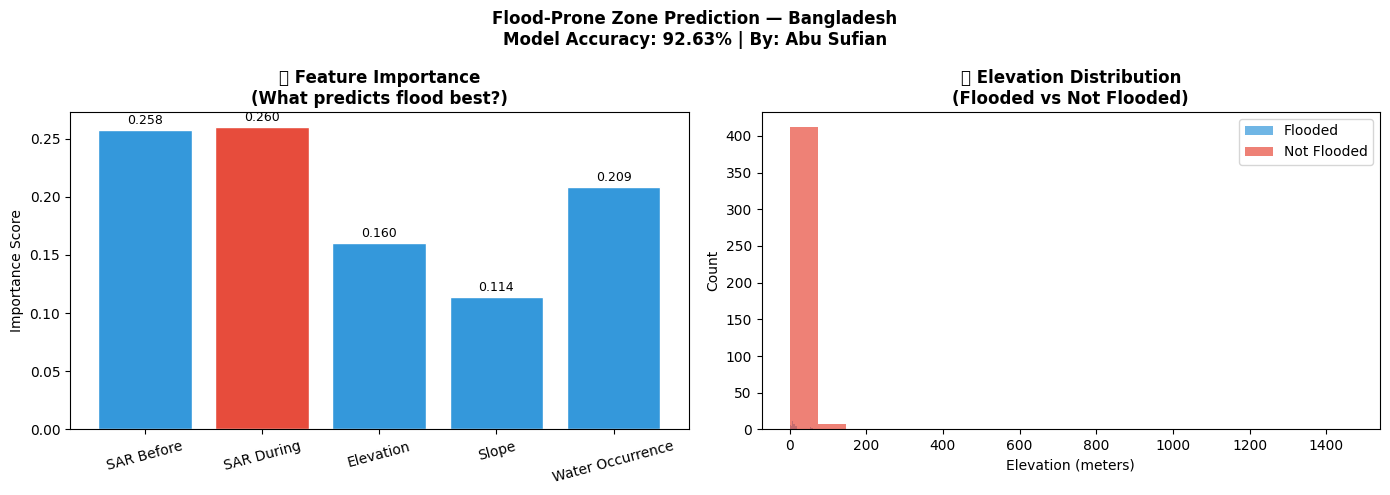

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Chart saved and downloading!


In [12]:
# Clean data
df = df.dropna()

X = df[['SAR_before', 'SAR_during', 'elevation', 'slope', 'water_occurrence']]
y = df['flood_label']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Results
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy*100:.2f}%")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Feature Importance
features = ['SAR Before', 'SAR During', 'Elevation', 'Slope', 'Water Occurrence']
importance = model.feature_importances_
colors = ['#e74c3c' if i == importance.argmax() else '#3498db' for i in range(len(features))]
bars = axes[0].bar(features, importance, color=colors, edgecolor='white')
axes[0].set_title('🤖 Feature Importance\n(What predicts flood best?)', fontweight='bold')
axes[0].set_ylabel('Importance Score')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, importance):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9)

# Plot 2 - Flood vs Non-Flood distribution
flood_elev = df[df['flood_label']==1]['elevation']
noflood_elev = df[df['flood_label']==0]['elevation']
axes[1].hist(flood_elev, bins=20, alpha=0.7, color='#3498db', label='Flooded')
axes[1].hist(noflood_elev, bins=20, alpha=0.7, color='#e74c3c', label='Not Flooded')
axes[1].set_title('🌊 Elevation Distribution\n(Flooded vs Not Flooded)', fontweight='bold')
axes[1].set_xlabel('Elevation (meters)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(f'Flood-Prone Zone Prediction — Bangladesh\nModel Accuracy: {accuracy*100:.2f}% | By: Abu Sufian',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('flood_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Download
from google.colab import files
files.download('flood_prediction_results.png')
print("✅ Chart saved and downloading!")